# Quantum Phase Estimation of a Qubitized Hamiltonian

## Part II. Block Encoding

As a reminder, this kata consists of five parts:

1. [Part I](./QubitizedHamiltonianQPE_1_Hamiltonian.ipynb) walks you through the theoretical construction of the Hamiltonian we'll use as the example and its mathematical properties.
2. Part II (this notebook) implements and validates the block encoding of this Hamiltonian as a Workbench program.
3. [Part III](./QubitizedHamiltonianQPE_3_QPE.ipynb) builds on top of part II, implementing a qubitization iterate based on the block encoding and running quantum phase estimation to reveal some numeric properties of our Hamiltonian.
4. [Part IV](./QubitizedHamiltonianQPE_4_QRE.ipynb) demonstrates basic resource analysis of our program, using Workbench QRE tools and algorithmic insight to help optimize our solution.
5. [Part V](./QubitizedHamiltonianQPE_5_LandscapeAnalysis.ipynb) walks you through a more advanced example of resource analysis of our program, showing how to plot the algorithm's resource costs as a function of its parameters and to analyze any irregularities in its behavior.

In this notebook, we'll see how to implement the block encoding of the Hamiltonian we've constructed in part I and how to test each building block of the code.

## Block encoding: The steps

Our strategy for probing the properties of the system on a quantum computer is to encode it as a _qubitization iterate_ built upon a _block encoding_ of the Hamiltonian. You can learn more about this in the [Linear Combination of Unitaries and Block Encoding kata](https://github.com/PsiQ/workbench-quantum-katas/blob/main/LCUBlockEncoding/LCUBlockEncoding.ipynb).

> Our Hamiltonian is already represented as a linear combination of unitaries, though the unitaries we use in this case are not tensor products of Pauli matrices that are commonly used as an example of the LCU technique. Instead, our six unitaries are "increment/decrement by 1/2/3 modulo $N$".

The block encoding consists of two main components:

1. A PREPARE state preparation unitary that acts on an auxiliary register to prepare the coefficients $\sqrt{\omega_j / \lambda}$, where $\lambda = 2\sum_j |\omega_j|$ is the $1$-norm of the Hamiltonian.
2. A SELECT self-inverse unitary that maps computational basis states in the auxiliary register to the unitary terms in the Hamiltonian which are applied onto the system register.

The figure below shows how these can be used to build the block encoding:

<div align="center">
    <img src="images/block_encoding.png" width="600">
</div>

This notebook will focus on building and validating these components and composing them into block encoding. In the next part of the kata, we will convert this construction into a qubitization iterate and plug it into quantum phase estimation.

## State preparation

Conceptually, state preparation is straightforward: given a list of coefficients, prepare a state whose amplitudes correspond to those coefficients. We will cover exactly how to do this when we get to the code implementation. For now, we simply give the explicit form of the state we will prepare:

$$
\text{PREPARE}\ket{0^{\otimes 2}}_{\text{coefficients}}\ket{0}_{\text{add/subtract}} = 
\sum_{j=0}^2 \sqrt{\frac{\omega_{j+1}}{\sum_k |\omega_k|}}\ket{j}_{\text{coefficients}}
\sum_{\sigma=0}^1 \frac1{\sqrt2}\ket{\sigma}_{\text{add/subtract}}
$$

Here the register indexed by $\ket{j}$ dispatches over the different hopping terms and the register indexed by $\sigma$ determines whether we apply a sum or a difference term. For bookkeeping, we'll refer to the $\ket{j}$ register as the "coefficients register" and the $\ket{\sigma}$ register as the "add/subtract register".

We split the auxiliary register up like this for two reasons. First, it makes the state preparation unitary slightly easier, since the add/subtract register can be prepared with just a single Hadamard gate. Second, it makes the SELECT implementation easier as well: a clean factorization of the different degrees of freedom for the problem into different registers allows us to similarly factorize the conditional application of the individual terms.

> This approach may seem like a contrivance for this kata, but it should be noted that this is a _very_ common strategy in quantum algorithm design. For example, we often use it to factorize out the spin degrees of freedom in fermionic systems.

Preparing the add/subtract register using a Hadamard gate is trivial, so we will not spend time on it. Instead, we will focus on preparing the coefficients register.

### Exercise 1. State preparation in Workbench

Fill in the missing parts in the following code which walks you through building a basic Workbench program that instantiates a library Qubrick for state preparation and uses this Qubrick to prepare a simple state.

> You can learn more about the algorithms for preparing arbitrary quantum states in the [Preparing Arbitrary Quantum States](https://github.com/PsiQ/workbench-quantum-katas/blob/main/ArbitraryStatePreparation/ArbitraryStatePreparation.ipynb) kata.

This program is executed using Workbench [state vector simulator](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Simulating-WB-Programs.html#state-vector-simulator), which is part of the default setup of a QPU object. It uses QPU methods `print_state_vector` and `draw`, useful for debugging quantum programs; you can read more about these and similar tools in the [Testing and Debugging tutorial](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Testing-Debugging.html).

In [1]:
from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms import ArbitraryStatePrep

# Create a QPU object with 2 qubits
qpu = ...

# Allocate a fresh register with 2 qubits
reg = ...

amplitudes = [0.6, 0.48, 0.64]
# Instantiate the state preparation Qubrick.
# Remember to pass the amplitudes as the argument to the constructor
state_prep = ...

# Prepare the state using a method of the state_prep object
...

# Print the state vector using a method of the qpu object
...

# Draw the circuit using a method of the qpu object
...

Ellipsis

## SELECT

For SELECT, we want to apply each Hamiltonian term onto the system register, conditioned on the basis states of the coefficients and add/subtract registers. For our system, the mathematical expression for SELECT is:

$$
\begin{align*}
\text{SELECT} :=  \sum_{j=0}^2 \ket{j}\bra{j}_{\text{coefficients}} \otimes \Bigg( \sum_{k=0}^{N-1} & \ket{0}\bra{1}_{\text{add/subtract}} \otimes \ket{k + j + 1}\bra{k}_{\text{system}}  \\ +
&\ket{1}\bra{0}_{\text{add/subtract}} \otimes \ket{k - j - 1}\bra{k}_{\text{system}} \Bigg)
\end{align*}
$$

We can translate this to a concrete circuit for implementing SELECT as follows:

1. Conditioned on the coefficients register being in state $\ket{j}$, load the value $j+1$ into another clean auxiliary register. We'll call this register "addends", since it stores the values we add/subtract on the next step.
2. Conditioned on the add/subtract register being in state $\ket{0}$ or $\ket{1}$, add or subtract the output of the first step to the system register.
3. Flip the value in the add/subtract register. This isn't strictly necessary to obtain a valid SELECT, but without it the SELECT operation isn't self-inverse, which causes problems if we want to plug the block encoding into QPE. (This can be done before or after the second step.)
4. Uncompute step 1.

Here is the corresponding circuit diagram for SELECT:

<div align="center">
    <img src="images/select.png" width="600">
</div>

The hexagon control structure in the diagram above should be interpreted as a multiplexor, a construction in which we loop over the basis states of an index register and apply an operation conditioned on each basis state. In this case, the operations are simply X gates encoding different integers:

<div align="center">
    <img src="images/multiplexor_generic.png" width="600">
</div>

## Data loading

The first step of our SELECT implementation is loading classical data: for each basis state $\ket{j}$ of one quantum register, we need to load the value $\ket{j+1}$ into another quantum register. This is a special case of the more general data loading task, in which we need to load arbitrary data. Let's see how to implement this in Workbench!

### Problem 1. Load data

**Inputs:** 

1. A `Qubits` register `index` of length $n$ in an arbitrary superposition state.
2. A `Qubits` register `target` of length $m$ in the $\ket{0}$ state.
3. A list of integers `data`, represented as `list[int]`. `data` will have at most $2^n$ elements, each element will be between $0$ and $2^m-1$, inclusive.
4. (Optional) A `Qubits` register `ctrl` of length $1$ in an arbitrary state - the control register for calling the controlled variant of the data loading unitary.

**Goal:** Load the data into register `target`, indexed by the value of the register `index`. In other words, for each basis state $\ket{j}$ that is within the range of indices of `data`, transform the input state as follows:

$$\ket{j}_{index}\ket{0}_{target} \rightarrow \ket{j}_{index}\ket{data_j}_{target}$$

For any basis states outside of range of indices of `data`, leave the corresponding components of the input state unchanged.
If the control register `ctrl` is not `None`, apply the controlled variant of the described transformation instead.

> Both the index $\ket{j}$ and the value $\ket{data_j}$ should be expressed in binary using little-endian encoding.

In [2]:
from psiqdk.workbench import Qubits, Qubrick
from test_QubitizedHamiltonianQPE import problem

@problem
class DataLoader(Qubrick):
    def _compute(self, index: Qubits, target: Qubits, data: list[int], ctrl: Qubits | None = None) -> None:
        """Load the data into register `target`, indexed by the value of the register `index`."""
        # Iterate over the elements of data
        ...
        # For each element of data, load it into register `target`
        # if register `index` is in the corresponding basis state.
        # Remember to control each gate on register `ctrl`!
        ...

Incorrect
Testing loading data=[1, 2, 3]
Error for j=0, ctrl=1: the state of the target register is 0, expected 1


## Addition

The second step of our SELECT implementation is addition. Quantum arithmetic is very common in quantum algorithms, and addition is one of the easiest arithmetic operations to implement. Let's give it a try!

> In this kata, we will implement the entire adder in a single task, using the naive addition algorithm. You can learn more about Workbench representation of numbers as quantum data types using little-endian encoding and the naive addition algorithm in the [Arithmetic Data Types](https://github.com/PsiQ/workbench-quantum-katas/blob/main/ArithmeticDataTypes/ArithmeticDataTypes.ipynb) kata, and about alternative quantum addition algorithms in the [Quantum Adders](https://github.com/PsiQ/workbench-quantum-katas/blob/main/Adders/Adders.ipynb) kata. You can use the same katas to learn more about testing quantum adders as reversible computations.

### Problem 2. Add two unsigned integers

**Inputs:** 

1. A `Qubits` register of length $N$ in an arbitrary superposition state $\ket{a}$.
2. A `Qubits` register of length $M \le N$ in an arbitrary superposition state $\ket{b}$.
3. (Optional) A `Qubits` register `ctrl` of length $1$ in an arbitrary state - the control register for calling the controlled variant of the addition unitary.

**Goal:** 
Add the number $b$ to the number $a$ modulo $2^N$. Leave the register $\ket{b}$ unchanged. In other words, implement the following transformation: 

$$\ket{a}\ket{b} \rightarrow \ket{(a + b) \textrm{ mod } 2^N}\ket{b}$$

If the control register `ctrl` is not `None`, apply the controlled variant of the described transformation instead.

> Note that the testing harness assumes that your implementation doesn't use any auxiliary qubits. Since this routine will be used as part of a larger algorithm that we'll run on a simulator, we want to implement the most qubit-efficient algorithm, even if it is very inefficient in terms of gates!

In [3]:
from psiqdk.workbench import Qubits, Qubrick
from test_QubitizedHamiltonianQPE import problem

@problem
class Adder(Qubrick):
    def _increment(self, a: Qubits, ctrl: Qubits | None = None) -> None:
        """Increment a register, with an optional quantum control."""
        # Write your code here
        ...

    def _compute(self, a: Qubits, b: Qubits, ctrl: Qubits | None = None, **kwargs) -> None:
        """Add register b to register a in-place, with an optional quantum control."""
        # Write your code here
        ...

Incorrect
Testing n=2, m=1
Error for a=0, b=1, ctrl=1: expected result a=1, got 0


## Block encoding: putting it all together

Now that we've built out all the components for the block encoding, let's combine them to build the full implementation! 

> Don't worry if you didn't get to finish implementing the data loader and adder from earlier tasks! We will provide the default library implementations from [PsiQDK Algorithms](https://docs.construct.psiquantum.com/psiqdk-algorithms/) to use for each component.

To start with, we'll define a Qubrick `HamiltonianEncoding` which constructs the block encoding of our Hamiltonian from a state preparation routine, a data loader (QROM), and an adder. (This will allow us the flexibility to swap the building blocks in the later parts of the katas.)

In [4]:
from psiqdk.workbench import Qubrick, Qubits

class HamiltonianEncoding(Qubrick):

    def __init__(
        self,
        prepare,
        qrom,
        adder,
        **kwargs,
    ):
        self.prepare = prepare
        self.qrom = qrom
        self.adder = adder
        super().__init__(**kwargs)

    def _compute(
        self,
        state_reg: Qubits,
        coefficients_reg: Qubits,
        add_subtract_reg: Qubits,
        ctrl: int | Qubits=0,
    ):
        # PREPARE
        self.prepare.compute(coefficients_reg, cond=ctrl)  # Coefficients
        add_subtract_reg.had(cond=ctrl)                    # Add/subtract

        addends = self.alloc_temp_qreg(2, "addends")
        # QROM
        # computed handles uncomputation automatically when we exit the context manager
        with self.qrom.computed(coefficients_reg, addends, [1, 2, 3], ctrl=ctrl):
            # Apply the trick to make the SELECT self-inverse
            add_subtract_reg.x(cond=ctrl)
            
            # Apply adder
            adder.compute(state_reg, addends, ctrl=(add_subtract_reg == 0) | ctrl)
            # Apply subtractor as adjoint of adder
            adder.compute(state_reg, addends, ctrl=(add_subtract_reg == 1) | ctrl, dagger=True)

        # after uncomputing the QROM, addends are back in |0> and can be released
        addends.release()

        # UnPREPARE
        add_subtract_reg.had(cond=ctrl)                    # Add/subtract
        self.prepare.uncompute()                           # Coefficients

Next, we will use this block encoding in a circuit, just to see how to instantiate it and what the result looks like.

> If you implemented the data loader and/or the adder in earlier problems, this is where you can use them as arguments for instantiating the block encoding Qubrick.

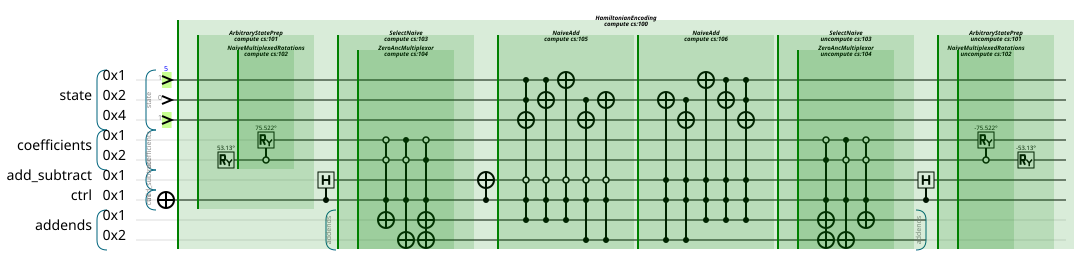

In [5]:
import numpy as np
from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms import ArbitraryStatePrep, SelectNaive, NaiveAdd

ws = [0.5, 0.3, 0.2]
basis_state = 5

qpu = QPU(num_qubits=9)

# Allocate the necessary registers
state_reg = Qubits(3, "state", qpu)
coefficients_reg = Qubits(2, "coefficients", qpu)
add_subtract_reg = Qubits(1, "add_subtract", qpu)
ctrl = Qubits(1, "ctrl", qpu)

# Initialize the registers that act as inputs
ctrl.x()
state_reg.write(basis_state)

# Instantiate the Qubricks used as building blocks for block encoding
prepare = ArbitraryStatePrep([np.sqrt(w) for w in ws])

# If you completed problem 1, you can use DataLoader() here instead
qrom = SelectNaive()

# If you completed problem 2, you can use Adder() here (keep the argument)
adder = NaiveAdd(allow_multi_qubit_ctrl=True)

# Instantiate the block encoding Qubrick
enc = HamiltonianEncoding(prepare, qrom, adder)

# Apply the block encoding
enc.compute(
    state_reg,
    coefficients_reg,
    add_subtract_reg,
    ctrl
)

qpu.draw(show_qubricks=True)

You can see that the circuit indeed looks like our circuit diagrams from earlier.

## Testing block encodng

Of course, visual checks are nice, but they are hardly a water-tight check that the algorithm implementation is correct. To validate that, we need to perform some more quantitative tests.

### State vector tests

The first set of tests we can run are state vector tests. We know what the input state was, and we know what the unitary applied to it should be, so we can deduce what the state after the circuit execution should look like.

We started with the `state_reg` register in the state $|5\rangle \equiv |101\rangle$. The coefficients of the Hamiltonian are $\omega_1 = 0.5, \omega_2 = 0.3, \omega_3 = 0.2$. From our earlier mathematical analysis in [part I](./QubitizedHamiltonianQPE_1_Hamiltonian.ipynb), we know that in the subspace where we successfully apply our block encoded Hamiltonian, we should obtain the state

$$
\begin{align*}
\frac{H^{(3)}\ket{5}}{\left|\left|H^{(3)}\ket{5}\right|\right|_2} 
&= \frac{1}{\sqrt{2\left(|\omega_1|^2 + |\omega_2|^2 + |\omega_3|^2\right)}} \bigg(\omega_1\left(\ket{6} + \ket{4}\right) + \omega_2\left(\ket{7} + \ket{3}\right) + \omega_3\left(\ket{0} + \ket{2}\right) \bigg) \\
&= \frac{1}{\sqrt{2\left(0.5^2 + 0.3^2 + 0.2^2\right)}} \bigg(0.5\left(\ket{6} + \ket{4}\right) + 0.3\left(\ket{7} + \ket{3}\right) + 0.2\left(\ket{0} + \ket{2}\right) \bigg) \\
&= \frac{1}{0.8718} \bigg(0.5\left(\ket{6} + \ket{4}\right) + 0.3\left(\ket{7} + \ket{3}\right) + 0.2\left(\ket{0} + \ket{2}\right) \bigg) \\
&= 0.5735 \left(\ket{6} + \ket{4}\right) + 0.3441\left(\ket{7} + \ket{3}\right) + 0.2294\left(\ket{0} + \ket{2}\right)
\end{align*}
$$

So let's check that we get this state!

There is a subtlety we need to deal with first though: we only get this state in the _successful_ branch of the block encoding &mdash; that is, the case in which the auxiliary registers are in the $\ket{0}$ state.

So our steps are:

1. Postselect on the block encoding auxiliary registers being in $\ket{0}$.
2. Check that the resulting state on `state_reg` is $0.5735 \left(\ket{6} + \ket{4}\right) + 0.3441\left(\ket{7} + \ket{3}\right) + 0.2294\left(\ket{0} + \ket{2}\right)$

Note that before postselecting, we can check the _probability_ of being in the correct state to make sure that is also correct.

The probability of being in the "good" subspace in block encoding is given by

$$
\frac{\left|\left|H^{(3)}\ket{5}\right|\right|_2^2}{\lambda^2} = \frac{2\left(0.5^2 + 0.3^2 + 0.2^2\right)}{2^2\left(0.5 + 0.3 + 0.2\right)^2} = 0.19
$$

We can check this probability using the `peek_read_probability` method of the Qubits object before we do postselection and pull the state using the `pull_state` method.

> You can read more about Workbench tools for inspecting quantum states and postselecting on measurement outcomes in the [Testing and Debugging tutorial](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Testing-Debugging.html).

In [6]:
# First check: Check the probability that the auxiliary registers are in the |0⟩ state
assert np.isclose((coefficients_reg | add_subtract_reg).peek_read_probability(0), 0.19)

# Second check: Apply postselection
coefficients_reg.postselect(0)
add_subtract_reg.postselect(0)

# Pull the state and print it
final_state = state_reg.pull_state()
qpu.print_state_vector()

# Check that the state of the register matches our expectation
expected_state = [0.2294, 0., 0.2294, 0.3441, 0.5735, 0., 0.5735, 0.3441]

assert np.allclose(expected_state, final_state, atol=5e-5)

|state|coefficients|add_subtract|ctrl|?>
|0|0|0|1|.>    0.229416+0.000000j
|2|0|0|1|.>    0.229416+0.000000j
|3|0|0|1|.>    0.344124+0.000000j
|4|0|0|1|.>    0.573539+0.000000j
|6|0|0|1|.>    0.573539+0.000000j
|7|0|0|1|.>    0.344124+0.000000j


Writing out the probability check and expected state by hand every time we want to update our system is clearly not going to scale. We can wrap this in a test function so we can run it over a wide variety of inputs, just to be sure our implementation works correctly:

In [7]:
def build_and_compute_block_encoding_postselected(
    ws: list[float],
    basis_state: int,
    qpu: QPU,
    postselect: bool = True,
) -> Qubits:    
    state_reg = Qubits(3, "state", qpu)
    coefficients_reg = Qubits(2, "coefficients", qpu)
    add_subtract_reg = Qubits(1, "add_subtract", qpu)
    ctrl = Qubits(1, "ctrl", qpu)

    ctrl.x()
    state_reg.write(basis_state)
    
    prepare = ArbitraryStatePrep([np.sqrt(w) for w in ws])
    qrom = SelectNaive()
    adder = NaiveAdd(allow_multi_qubit_ctrl=True)
    
    enc = HamiltonianEncoding(prepare, qrom, adder)
    
    enc.compute(
        state_reg,
        coefficients_reg,
        add_subtract_reg,
        ctrl
    )

    # Check we get the right probability of success before doing postselection
    state_norm = np.sqrt(sum(2 * np.abs(w) ** 2 for w in ws))
    ham_norm = 2 * sum(ws)
    assert np.isclose(
        (coefficients_reg | add_subtract_reg).peek_read_probability(0),
        state_norm ** 2 / ham_norm ** 2,
    )
    
    if postselect:
        coefficients_reg.postselect(0)
        add_subtract_reg.postselect(0)

    # Uncompute ctrl (not strictly necessary, but makes pulling the state after much easier)
    ctrl.x()

    return state_reg


def check_computed_state_matches_expected(
    ws: list[float], 
    basis_state: int, 
    state_reg: Qubits
) -> None:
    state_norm = np.sqrt(sum(2 * np.abs(w) ** 2 for w in ws))
    num_basis_states = 2 ** state_reg.num_qubits

    # The expected state is the (normalized) column of the matrix
    # that corresponds to the input basis state
    expected_state = [0.] * num_basis_states
    for j in range(1, 4):
        coeff = (1 / state_norm) * ws[j - 1]
        expected_state[(basis_state + j) % num_basis_states] = expected_state[(basis_state - j) % num_basis_states] = coeff

    assert np.allclose(state_reg.pull_state(), expected_state)


def test_computed_output_state_matches_expected_all_basis_states(ws: list[float]):
    num_state_qubits = 3
    num_aux_qubits = 6  # 2 from coefficients, 1 for add/subtract, one for ctrl, 2 for addends
    qpu = QPU()

    # Run the test on each basis state
    for basis_state in range(2 ** num_state_qubits):
        qpu.reset(num_aux_qubits + num_state_qubits)
        state_reg = build_and_compute_block_encoding_postselected(ws, basis_state, qpu)
        check_computed_state_matches_expected(ws, basis_state, state_reg)

    print(f"Test for {ws=} passed!")


# Try running the test with different values, they should all work
test_computed_output_state_matches_expected_all_basis_states([0.1, 0.3, 0.2])

Test for ws=[0.1, 0.3, 0.2] passed!


### Unitary matrix tests

Another way to implement the same test is to directly check the matrix that our Qubrick implements. To do this, we can use Workbench's built-in `>>unitary>>` filter to extract the full unitary matrix and then post-process it to extract the top-left block of the right size.

> You can read more about the tooling for fetching the matrix of a unitary transformation in the [Testing and Debugging tutorial](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Testing-Debugging.html).

In [8]:
from test_QubitizedHamiltonianQPE import print_colored_matrix

num_state_qubits = 3
num_aux_qubits = 6
qpu = QPU(num_qubits=num_aux_qubits + num_state_qubits, post_filters=[">>unitary>>"])

ws = [0.5, 0.3, 0.2]

build_and_compute_block_encoding_postselected(
    ws=ws,
    basis_state=5,  # >>unitary>> filter does not actually use the state information
    qpu=qpu,
    postselect=False,
)

# Extract the full unitary matrix for the entire block encoding
unitary = qpu.get_filter_by_name(">>unitary>>").get()

# Get the top-left block (where we expect our Hamiltonian to live)
hamiltonian_block = unitary[:2 ** num_state_qubits, :2 ** num_state_qubits]

# Print the top-left block using the same function as in part I
norm = 2 * sum(ws)
print_colored_matrix(hamiltonian_block.real, [w / norm for w in ws])

0.0,0.25,0.15,0.1,0.0,0.1,0.15,0.25
0.25,0.0,0.25,0.15,0.1,0.0,0.1,0.15
0.15,0.25,0.0,0.25,0.15,0.1,0.0,0.1
0.1,0.15,0.25,0.0,0.25,0.15,0.1,0.0
0.0,0.1,0.15,0.25,0.0,0.25,0.15,0.1
0.1,0.0,0.1,0.15,0.25,0.0,0.25,0.15
0.15,0.1,0.0,0.1,0.15,0.25,0.0,0.25
0.25,0.15,0.1,0.0,0.1,0.15,0.25,0.0


That looks great! Except...

What's going on with the matrix coefficients? The function `print_colored_matrix` highlights the matrix elements if they match any of the values in the input list. We had to divide the expected coefficients by the $1$-norm of the Hamiltonian to get the correct highlighting, but why?

Recall that our state preparation routine doesn't prepare the square roots of the coefficients, $\sqrt{\omega_j}$, directly, but rather prepares $\sqrt{\omega_j/\lambda}$, that is, coefficients normalized with respect to the Hamiltonian $1$-norm. After applying $\text{PREPARE}^\dagger$, the weight of each Hamiltonian term will thus be divided by the norm, leading to the expression above.

> This is actually one of the most important caveats when using block encoding to encode your Hamiltonian! Your eigenvalues are scaled by the $1$-norm of the Hamiltonian, and thus the higher the $1$-norm, the higher the precision required to get an accurate estimate of the energy. A large amount of research effort is spent in finding new representations of Hamiltonians that implement the same physics with a reduced $1$-norm for precisely this reason.

## Part II conclusion

In the second part of this kata, you've implemented the block encoding of the Hamiltonian we constructed in the first part. In [part III](./QubitizedHamiltonianQPE_3_QPE.ipynb), you will convert this block encoding into a qubitization iterate and use it with quantum phase estimation algorithm to learn the properties of the Hamiltonian we are exploring.